# Polynomial

A polynomial is a function expressed as a finite sum of powers of its variable. A polynomial of degree $n$ can be written as

$$
P(x) = a_0 + a_1x + a_2x^2 + \cdots + a_nx^n\sum_{k=0}^{n}a_kx^k,
$$

where $a_k$ are the polynomial coefficients. In NumPy, polynomials can be represented using `np.polynomial.Polynomial`. The coefficients are specified in increasing order of degree, so the array $[ a_0, a_1, a_2, \ldots, a_n ]$ represents the polynomial

$$
P(x) = a_0 + a_1x + \cdots + a_nx^n.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

## Polynomial Representation

Consider the polynomial

$$
P_1(x) = 1 + 2x + 3x^2
$$

and

$$
P_2(x) = -\frac{1}{2} + \frac{3}{2}x + \frac{1}{2}x^2.
$$

They can be represented directly using `np.polynomial.Polynomial`.

In [3]:
P1 = np.polynomial.Polynomial([1, 2, 3])
P1

Polynomial([1., 2., 3.], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

In [4]:
P2 = np.polynomial.Polynomial([-.5, 1.5, .5])
P2

Polynomial([-0.5,  1.5,  0.5], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

This coefficient-based representation allows polynomial operations to be performed directly without explicitly manipulating the individual terms.

## Polynomial Arithmetic

Polynomial objects support standard arithmetic operations. Addition and subtraction are performed coefficient-wise,

$$
(P_1 + P_2)(x) = P_1(x) + P_2(x),
$$

and

$$
(P_1 - P_2)(x) = P_1(x) - P_2(x).
$$

In [5]:
P1 + P2

Polynomial([0.5, 3.5, 3.5], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

In [6]:
P1 - P2

Polynomial([1.5, 0.5, 2.5], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

Polynomial multiplication follows the usual product of polynomials,

$$
(P_1 P_2)(x) = P_1(x) P_2(x),
$$

which generally increases the degree of the resulting polynomial.

In [7]:
P1 * P2

Polynomial([-0.5,  0.5,  2. ,  5.5,  1.5], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

## Polynomial Differentiation

A polynomial can be differentiated term by term. For

$$
P(x) = \sum_{k=0}^{n}a_kx^k,
$$

the first derivative is

$$
P'(x) = \sum_{k=1}^{n}ka_kx^{k-1}.
$$

Higher-order derivatives can be obtained by repeatedly applying differentiation. In NumPy, the derivative order is specified using the `m` parameter of `.deriv(m)`.

In [8]:
P1.deriv(1)

Polynomial([2., 6.], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

In [9]:
P2.deriv(2)

Polynomial([1.], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

## Polynomial Integration

The antiderivative of a polynomial is obtained by integrating each term:

$$
\int P(x)\,dx = C + \sum_{k=0}^{n}\frac{a_k}{k+1}x^{k+1},
$$

where $C$ is the integration constant. NumPy's `.integ()` method can be used to compute polynomial antiderivatives. The integration constant and lower-order integration terms can be specified through the method arguments.

In [10]:
P1.integ(1, 3)

Polynomial([3., 1., 1., 1.], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

In [11]:
P2.integ(2, (1, 5))

Polynomial([ 5.        ,  1.        , -0.25      ,  0.25      ,  0.04166667], domain=[-1.,  1.], window=[-1.,  1.], symbol='x')

## Polynomial Evaluation

Once a polynomial has been constructed, it can be evaluated at arbitrary values of $x$. Consider

$$
P(x) = 1 + 2x + 3x^2.
$$

Evaluating the polynomial over a range of $x$ values produces the corresponding function values,

$$
y=P(x).
$$

These values can then be visualized to examine the behavior of the polynomial over the selected interval.

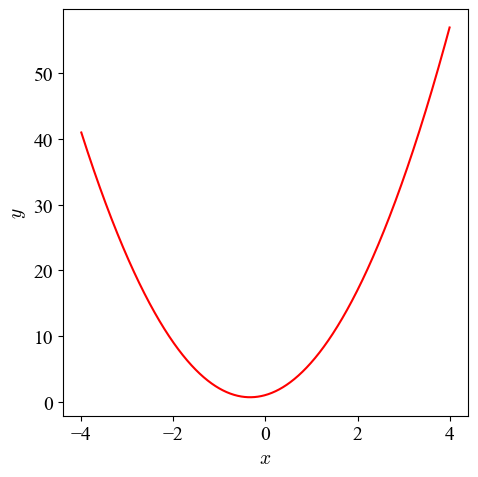

In [12]:
P = np.polynomial.Polynomial([1, 2, 3])
x = np.linspace(-4, 4, 1000)
plt.figure(figsize=(5, 5))
plt.plot(x, P(x), color="r")
plt.xlabel(r"$x$")
plt.ylabel(r"$y$")
plt.tight_layout()
plt.show()